# Cascade — Ki sweep (0 to 1, step 0.05)

Explores how the default cascade depends directly on the failure buffer `Ki` (not via `p`).
For each `Ki` it runs the per-node cascade and plots the cascade-size distribution. **Nothing is saved.**
Network: `dataset_3` (ER, avg degree 0.8) — change `EDGES` to use another.

In [5]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'requirements.txt').exists())
EDGES = R"financial-contagion-in-R/network_ba_avgdeg_1_edges.csv"
N = 10000
KI_LIST = np.round(np.arange(0.0, 1.0001, 0.05), 2)   # 0.00, 0.05, ..., 1.00

In [6]:
def load_graph():
    e = pd.read_csv(EDGES)
    out = [[] for _ in range(N + 1)]
    for f, t, w in zip(e['from'], e['to'], e['weight']):
        out[f].append((t, w))
    return out

def cascade_size(out, src, ki):
    accum = np.zeros(N + 1); failed = np.zeros(N + 1, bool)
    failed[src] = True; stack = [src]; size = 1
    while stack:
        b = stack.pop()
        for i, w in out[b]:
            if not failed[i]:
                accum[i] += w
                if accum[i] > ki:
                    failed[i] = True; size += 1; stack.append(i)
    return size

## Run the Ki sweep (no saving)

In [7]:
EDGES = ROOT / EDGES
out = load_graph()
dist = {}
for ki in KI_LIST:
    sizes = np.array([cascade_size(out, v, ki) for v in range(1, N + 1)])
    dist[ki] = sizes
    print(f'Ki={ki:.2f}  mean={sizes.mean():.1f}  max={sizes.max()}')

Ki=0.00  mean=6.0  max=15
Ki=0.05  mean=1.6  max=7
Ki=0.10  mean=1.2  max=4
Ki=0.15  mean=1.2  max=4
Ki=0.20  mean=1.0  max=1
Ki=0.25  mean=1.0  max=1
Ki=0.30  mean=1.0  max=1
Ki=0.35  mean=1.0  max=1
Ki=0.40  mean=1.0  max=1
Ki=0.45  mean=1.0  max=1
Ki=0.50  mean=1.0  max=1
Ki=0.55  mean=1.0  max=1
Ki=0.60  mean=1.0  max=1
Ki=0.65  mean=1.0  max=1
Ki=0.70  mean=1.0  max=1
Ki=0.75  mean=1.0  max=1
Ki=0.80  mean=1.0  max=1
Ki=0.85  mean=1.0  max=1
Ki=0.90  mean=1.0  max=1
Ki=0.95  mean=1.0  max=1
Ki=1.00  mean=1.0  max=1


## Cascade-size distribution for each Ki

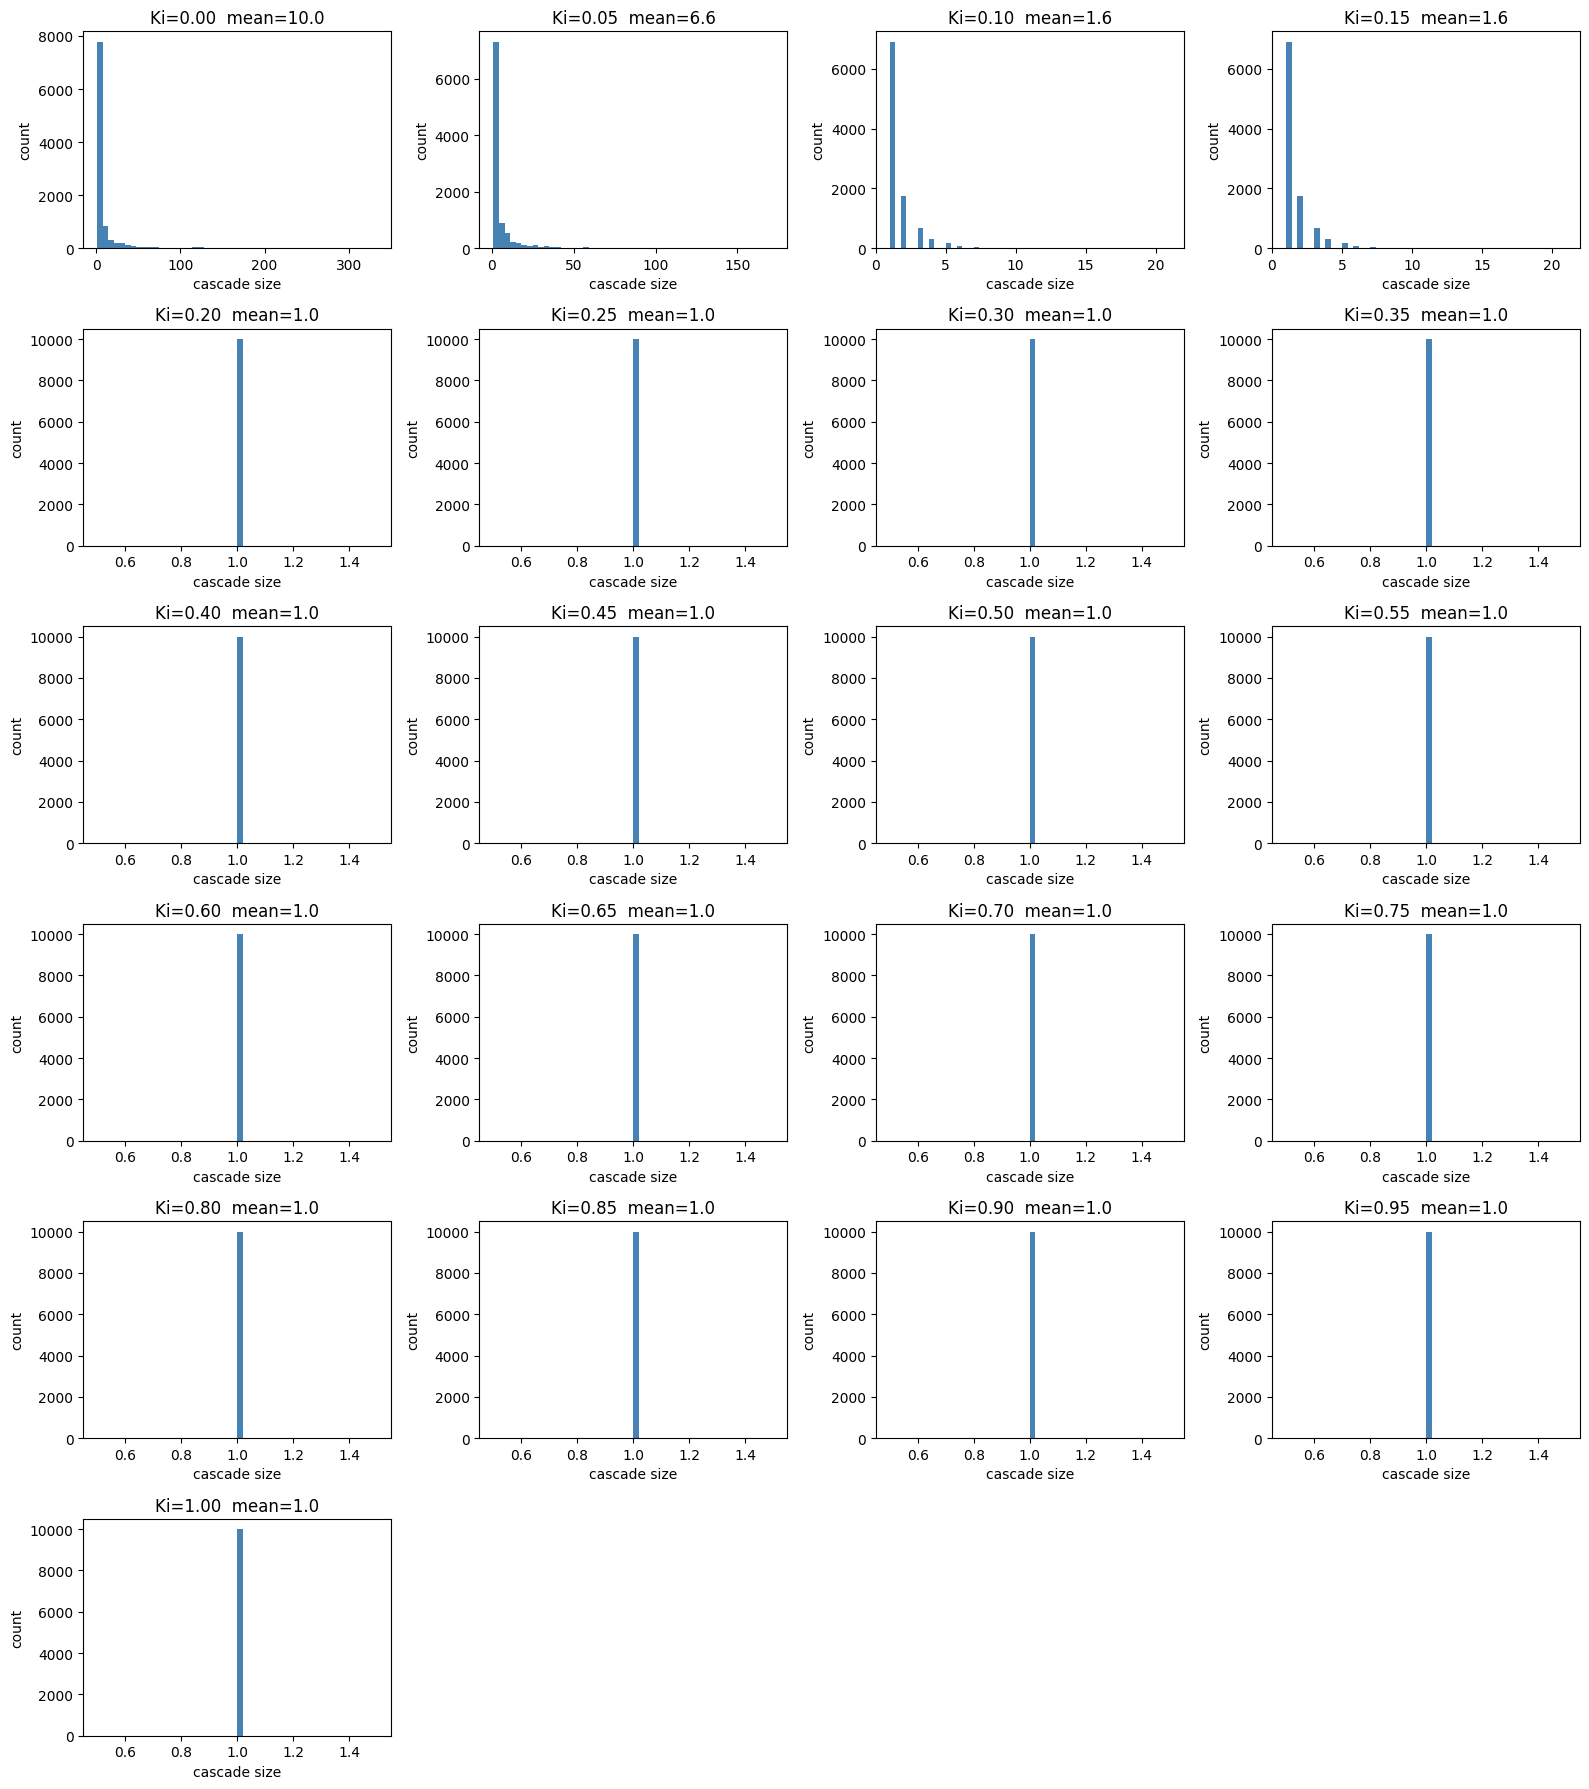

In [4]:
ncols = 4; nrows = math.ceil(len(KI_LIST) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows)); axes = axes.ravel()
for ax, ki in zip(axes, KI_LIST):
    ax.hist(dist[ki], bins=50, color='steelblue')
    ax.set_title(f'Ki={ki:.2f}  mean={dist[ki].mean():.1f}')
    ax.set_xlabel('cascade size'); ax.set_ylabel('count')
for ax in axes[len(KI_LIST):]:
    ax.set_visible(False)
fig.tight_layout(); plt.show()